# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Práctica: Regresión Lineal Múltiple
---


## Datos del Estudiante

*   Apellidos y Nombre: Aguirre Higuera, Pablo Alejandro
*   Matrícula: 263845

---



##  Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar regresión lineal múltiple utilizando Scikit-Learn para modelar la relación entre varias variables independientes y una variable dependiente**, verificar los supuestos del modelo, interpretar los coeficientes, analizar la correlación entre predictores y evaluar el rendimiento del modelo utilizando métricas como el MSE, RMSE y R².

Datos
Trabajarás con el archivo `advertising.csv`, que contiene información sobre el gasto publicitario en diferentes medios y las ventas obtenidas:

-`TV`: inversión en publicidad televisiva.

-`Radio`: inversión en publicidad en radio.

-`Newspaper`: inversión en publicidad en periódicos.

`Sales`: ventas del producto (variable dependiente).

## Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `advertising.csv`.
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente las variables.

In [1]:
# Tu código aquí
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import scipy.stats as stats
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("advertising.csv")
df.head(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [2]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


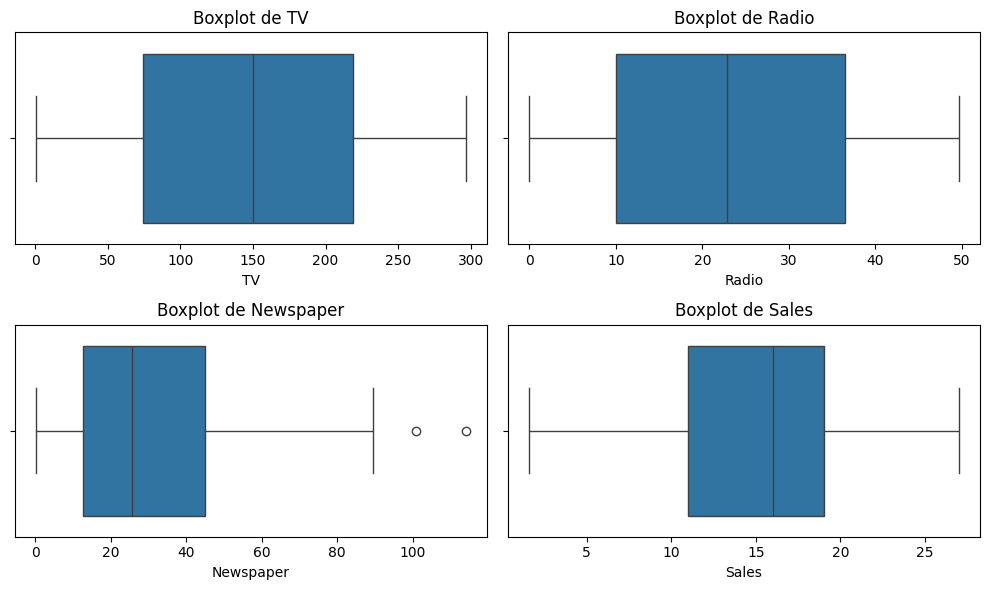

In [3]:
col_numericas = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10,6))

for i, col in enumerate(col_numericas, 1):
    plt.subplot(2, 2, i)  
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

Evidentemente se invierte más dinero en TV que en cualquier otro medio - y por mucho. Considérese que el cuantil 25 de TV es casi 50% más que el valor máximo de Radio. El periódico necesitaría de valores cercanos a su máximo para superar el cuantil 25 de la TV. 

Las inversiones en TV y radio parecen tener una distribución centrada dada la cercanía entre sus respectivaas medias y medianas. La inversión en el periódico presenta un sesgo a la derecha. Los valores cercanos al máximo inflan su media y desviación estándar.

Las ventas presentan un ligero sesgo a la izquierda, pero no presentan puntos atípicos.

## Parte 2: Análisis exploratorio de los datos
### 2.1  Análisis de la Relación Lineal entre la variable dependiente y las independientes
1. Grafica dispersión entre cada variable independiente (`TV`, `Radio`, `Newspaper`) y `Sales`. Usa también regplot.
2. Interpreta visualmente la relación entre variables.

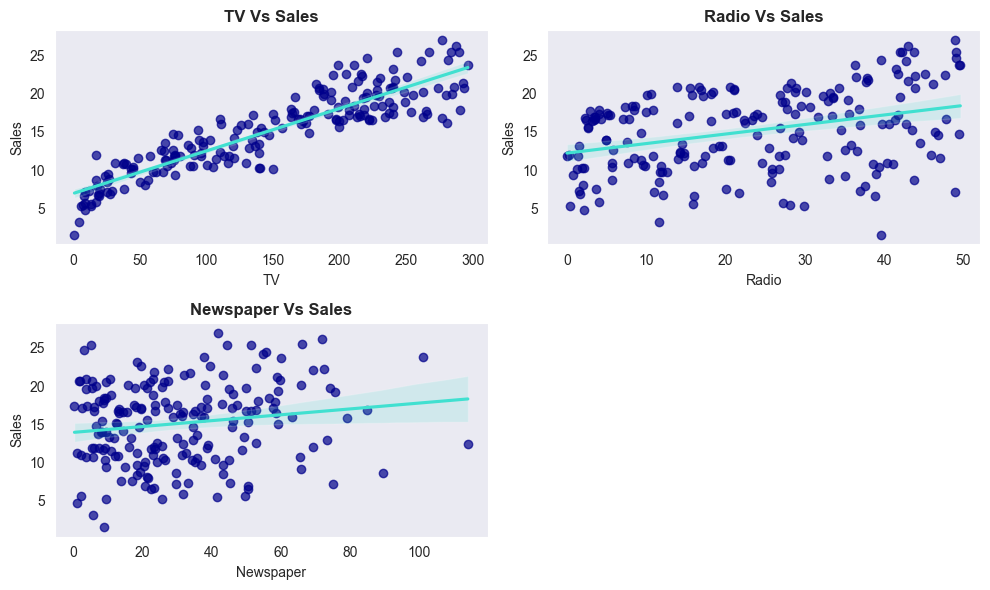

In [4]:
# Gráficos de dispersión
plt.figure(figsize=(10,6))
sns.set_style("dark")

for i, col in enumerate(col_numericas[:-1], 1):
    plt.subplot(2,2,i)
    sns.regplot(x=df[col], y=df["Sales"], scatter_kws={"alpha":0.7, "color" : "darkblue"}, line_kws={"color": "turquoise"})
    plt.title(f"{col} Vs Sales", fontweight="bold")

plt.tight_layout()
plt.show()

TV tiene una fuerte correlación lineal con las ventas; esta variable será la mejor predictora para un modelo de regresión lineal. No obstante, vale la pena mencionar que un modelo logarítmico podría obtener mejores resultados, aun siendo más complicado de interpretar que uno lineal. Nótese cómo los puntos cercanos a 0 en el eje de TV podrían aproximarse mejor con una función logarítmica.

Las demás variables muestran una corrleación moderada con las ventas, pero ya con más dispersión en los datos.

### 2.2: Correlación entre variables
1. Calcula la matriz de correlación.
2. Visualízala con un heatmap.
3. Responde: ¿Qué variables están más correlacionadas con `Sales`? ¿Hay correlación alta entre predictores?

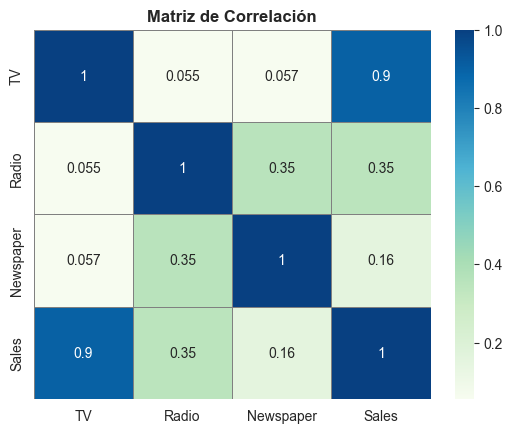

In [5]:
# Correlación y heatmap
matriz_corr = df.corr()
sns.heatmap(matriz_corr, annot=True, cbar=True, cmap="GnBu", linewidths=0.6, linecolor="gray")
plt.title("Matriz de Correlación", fontweight="bold")
plt.show()


Como se notó en los gráficos de dispersión, TV tiene una fuerte correlación con las ventas. El radio y el periódico presentan una ligera correlación con las ventas. La radio y el periódico tienen una correlación ligera el uno con el otro. No parece que la multicolinealidad vaya a ser un problema.

## Parte 3. Multicolinealidad
1. Calcula el VIF (Variance Inflation Factor) para cada predictor.
2. Crea un diagrama de barras  para mostrar el  VIF
3. Interpreta si hay multicolinealidad:
- ¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?
- ¿Qué implicaciones tiene esto para el modelo?

C:\Users\pablo\AppData\Local\Temp\ipykernel_16620\2262010476.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VIF', y='Variable', data=vif_data, palette='GnBu')


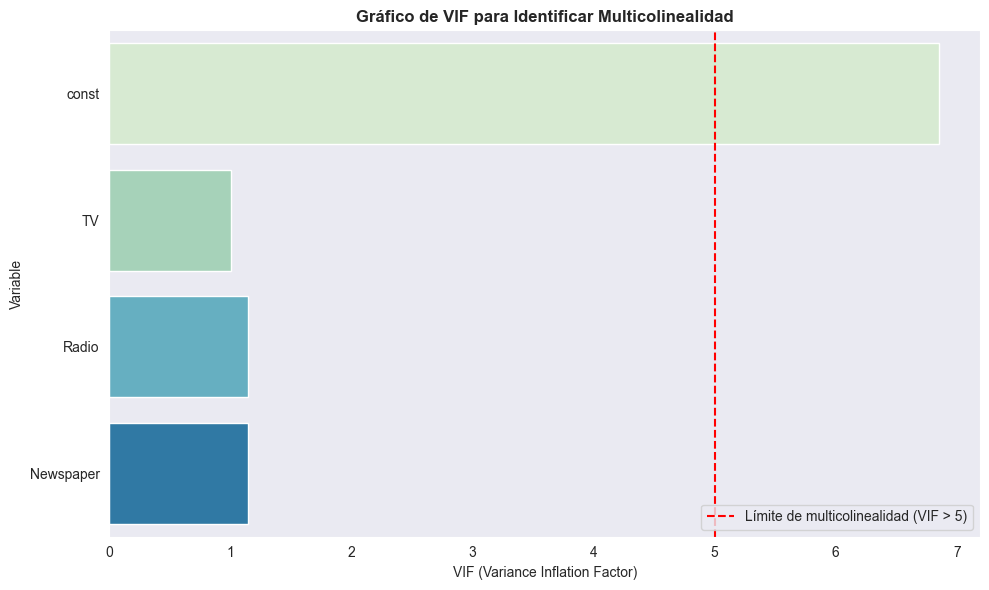

In [6]:
#Multicolinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df.drop(columns=["Sales"]))
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])] #X.shape es (200,4)

plt.figure(figsize=(10, 6))
sns.barplot(x='VIF', y='Variable', data=vif_data, palette='GnBu')
plt.axvline(x=5, color='red', linestyle='--', label='Límite de multicolinealidad (VIF > 5)')
plt.xlabel('VIF (Variance Inflation Factor)')

plt.title('Gráfico de VIF para Identificar Multicolinealidad', fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

En paralelo con la matriz de correlación, niguna de las variables predictores tiene correlación significativa entre ellas mismas. Lo que sí podría representar un problema es el intercepto del modelo con un VIF de casi 7. Esto se debe a que, como se comentó al principio, la distribución del periódico presenta un sesgo a la derecha por esos valores atípicos de 100 ventas. Habrá que estar al pendiente del intercepto y su impacto en el modelo.

## Parte 4: Construcción del Modelo (Todas las variables Independientes), Evaluación

### 4.1 Entrenamiento del Modelo (Todas las Variables Independientes)

1. Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
2. Imprime el intercepto y los coeficientes del modelo.
3. Interpreta cada uno:
¿Qué significa cada uno de los coeficientes  en términos de ventas?

In [7]:
#Entrenamiento del Modelo (Todas las Variables Independientes)
X = X.drop(columns="const")

modelo = LinearRegression()
modelo.fit(X, df["Sales"])

coeficientes = np.round(modelo.coef_,4)
intercepto = np.round(modelo.intercept_,4)

ecuacion = ""
for i, coef in enumerate(coeficientes):
    ecuacion += f"+ ({coef} * {X.columns[i]}) "

ecuacion += f"+ ({intercepto})"
print(ecuacion)

+ (0.0544 * TV) + (0.107 * Radio) + (0.0003 * Newspaper) + (4.6251)


El intercepto en este caso quizás puede indicar que hay otros medios que no se están considerando en marketing. Si los valores de TV, Radio y Newspaper son 0, ciertamente no es imposible tener 4 ó 5 ventas de un producto.

Curiosamente, la radio tiene un coeficiente mayor que la televisión a pesar de que esta última tiene correlación lineal mucho más alta con las ventas. Según el modelo, cada dolar invertido en la radio genera 0.107 ventas de producto.

### 4.2 Normalidad de los residuos

1. Calcula los residuos: residuos = y - y_pred.

2. Grafica un histograma con KDE de los residuos.

3. ¿Los residuos parecen distribuirse normalmente?

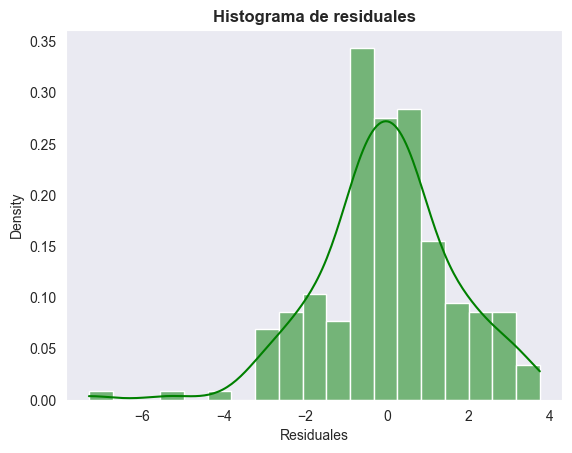

In [8]:
#Normalidad de los residuos
sales_pred = modelo.predict(X)
residuos = df["Sales"] - sales_pred

sns.histplot(residuos, kde=True, color="green", stat="density")
plt.title("Histograma de residuales", fontweight="bold")
plt.xlabel("Residuales")
plt.show()

La distribución de los residuales se asemeja a la forma de la campana de Gauss, solo que la cola izquierda muestra desviaciones serias de la campana de Gauss estándar.

### 4.3. Homocedasticidad

1. Grafica los residuos contra los valores predichos.
2. ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?

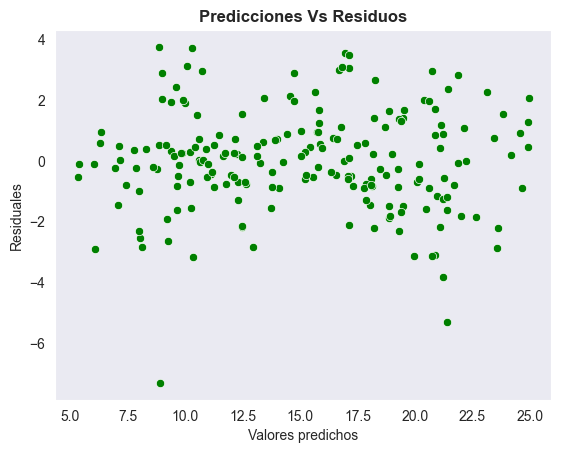

In [9]:
# Homocedasticidad
sns.scatterplot(x=sales_pred, y=residuos, color="green")
plt.title("Predicciones Vs Residuos", fontweight="bold")
plt.xlabel("Valores predichos")
plt.ylabel("Residuales")
plt.show()

No parece que sea suficiente para rechazar la homocedasticidad, pero al inferior de la nube de puntos se aprecia la forma de una parábola descendiente. Se asumirá que se cumple con el supuesto de la homocedasticidad.

### 4.4 Q-Q Plot

1. Graficar el Q-Q Plot
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal, b) Desviaciones sistemáticas indican asimetría o colas pesadas.

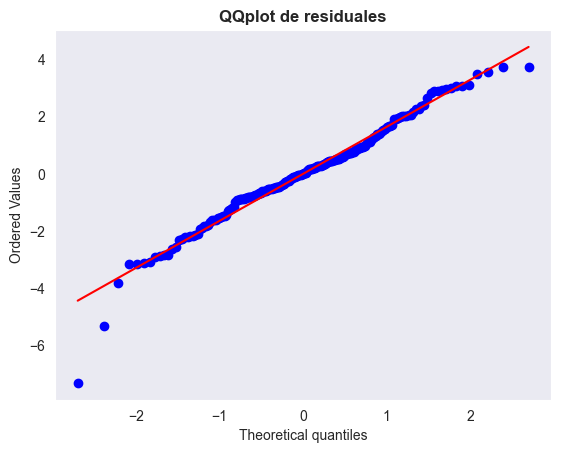

In [10]:
#Q-Q Plot
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("QQplot de residuales", fontweight="bold")
plt.show()

Tal como se observó con el histograma, la cola izquierda de la distribución está seriamente desviada de la normalidad. Fuera de ello, los residuales están distribuidos normalmente.

### 4.5. Evaluación del Modelo

1. Calcula las métricas: a) MSE (error cuadrático medio), b) RMSE (raíz del error cuadrático medio), c) R² (coeficiente de determinación)

2. ¿Qué nos dicen estas métricas sobre el ajuste del modelo?


In [11]:
#Evaluación del Modelo
mse = mean_squared_error(df["Sales"], sales_pred)
rmse = np.sqrt(mse)
r2 = r2_score(df["Sales"], sales_pred)

print(f"Error Cuadrático Medio (MSE): {mse:.3f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.3f}")
print(f"Coeficiente de Determinación (R²): {r2:.3f}")

Error Cuadrático Medio (MSE): 2.706
Raíz del Error Cuadrático Medio (RMSE): 1.645
Coeficiente de Determinación (R²): 0.903


De acuerdo a las métricas obtenidas, las predicciones se desvían, en promedio, 1.645 unidades. Esta desviación es bastante cercana a la realidad considerando una escala de 1 hasta 27. Se tiene que el modelo en su estado actual explica el 90.3% de la variación. 

### 4.6. Visualización de Predicciones

1. Crea un gráfico comparando Sales reales vs Sales predichas.

2. Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.
3. ¿Qué observas?¿Qué información puedes obtener de esta gráfica?

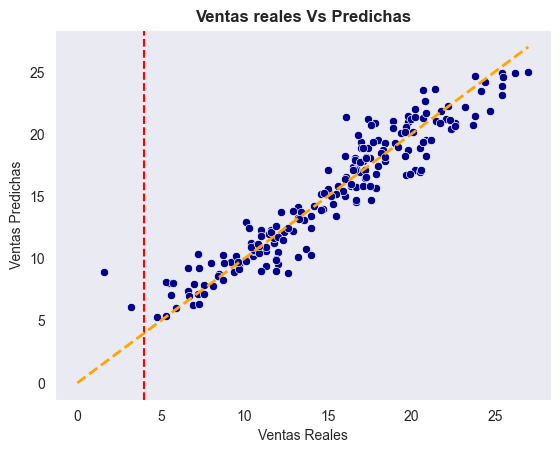

In [12]:
#Visualización de las Predicciones
sns.scatterplot(x=df["Sales"], y=sales_pred, color="darkblue")
plt.axvline(x=4, color="red", linestyle="--")
plt.plot(range(0,28), range(0,28), color="orange", linestyle="--", linewidth=2)

plt.title("Ventas reales Vs Predichas", fontweight="bold")
plt.xlabel("Ventas Reales")
plt.ylabel("Ventas Predichas")
plt.show()

La gráfica muestra cómo los puntos van siguiendo la forma de la recta naranja, y sin mayor dispersión; el modelo tiene un buen ajuste. Vale la pena investigar los 2 puntos del lado izquierdo la línea roja; estos también ocasionan que los residuales tengan sesgo a la izquierda.

### 4.7 Verificar el impacto de los atributos en el modelo

1. Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
2. Interpreta los resultados:

 - Observa los valores P>|t| en la tabla de salida.

 - ¿Qué variables tienen p-value menores a 0.05?

 - ¿Cuál es la conclusión sobre esas variables?


In [13]:
#P-values
import statsmodels.api as sm

X_sm = sm.add_constant(X)
modelo_sm = sm.OLS(df["Sales"], X_sm).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           8.13e-99
Time:                        12:51:29   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

El intercepto (const), TV, y la radio tienen una contribución significativa al modelo. El periódico no tiene una contribución significativa al modelo; puede prescindirse de esa variable. Los valores de Omnibus y JB reflejan que hay problemas con la normalidad de los residuales. Los datos a la izquierda de la línea roja en la gráfica de la sección 4.6 están detrás de esto. Finalmente, *Cond. No.* refleja un problema mayúsculo con la multicolinealidad; El intercepto tenía un VIF de casi 7.

## Parte 5:  Construcción del Modelo (sin Multicolinealidad), Evaluación

En el caso de que hayas detectado variables con multicolinealidad. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

In [14]:
#Entrenamiento
modelo_sin_mc = LinearRegression(fit_intercept=False) #Se elimina el intercepto
modelo_sin_mc.fit(X, df["Sales"])

coeficientes = np.round(modelo.coef_,4)

ecuacion = ""
for i, coef in enumerate(coeficientes):
    ecuacion += f"+ ({coef} * {X.columns[i]}) "

print(ecuacion)

+ (0.0544 * TV) + (0.107 * Radio) + (0.0003 * Newspaper) 


Nótese que estos son los mismos coeficientes del primer modelo (más adelante se dan detalles al respecto).

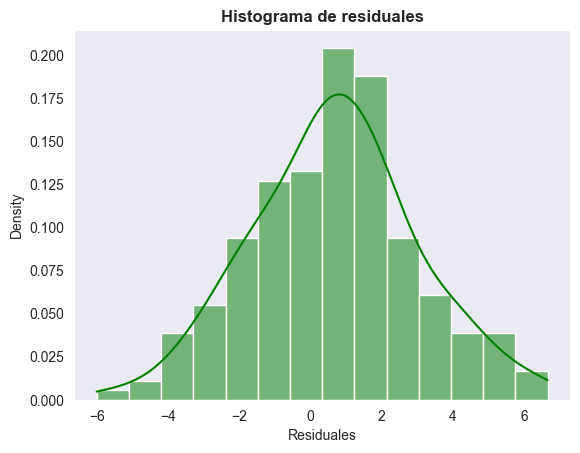

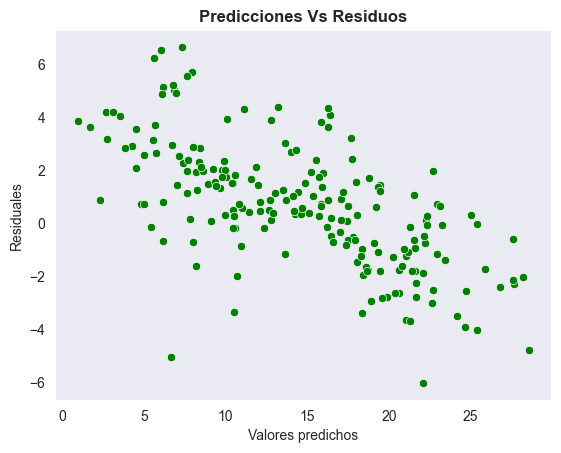

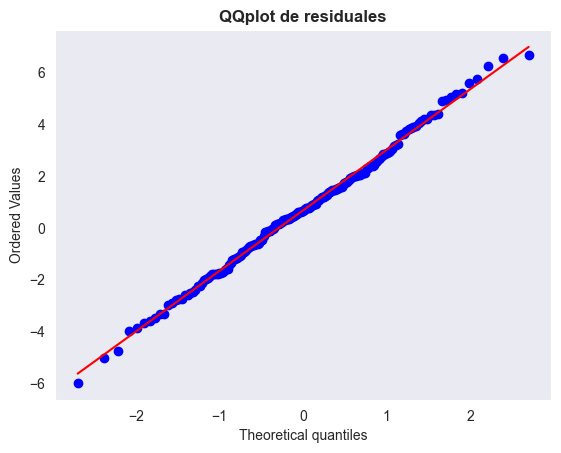

In [15]:
#Evaluacion de supuestos
sales_pred_sin_mc = modelo_sin_mc.predict(X)
residuos_sin_mc = df["Sales"] - sales_pred_sin_mc

sns.histplot(residuos_sin_mc, kde=True, color="green", stat="density")
plt.title("Histograma de residuales", fontweight="bold")
plt.xlabel("Residuales")
plt.show()

sns.scatterplot(x=sales_pred_sin_mc, y=residuos_sin_mc, color="green")
plt.title("Predicciones Vs Residuos", fontweight="bold")
plt.xlabel("Valores predichos")
plt.ylabel("Residuales")
plt.show()

stats.probplot(residuos_sin_mc, dist="norm", plot=plt)
plt.title("QQplot de residuales", fontweight="bold")
plt.show()

Eliminando el intercepto, se mejora la normalidad de los residuales. No obstante, esto ha sido a expensas de la homocedasticidad de los residuos. Se observa una tendencia lineal descendente a medida que aumentan los valores de las predicciones.

In [16]:
#Evaluación del modelo
mse = mean_squared_error(df["Sales"], sales_pred_sin_mc)
rmse = np.sqrt(mse)
r2 = r2_score(df["Sales"], sales_pred_sin_mc)

print(f"Error Cuadrático Medio (MSE): {mse:.3f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.3f}")
print(f"Coeficiente de Determinación (R²): {r2:.3f}")

Error Cuadrático Medio (MSE): 5.829
Raíz del Error Cuadrático Medio (RMSE): 2.414
Coeficiente de Determinación (R²): 0.790


Sin el intercepto, el ajuste del modelo empeoró. El coeficiente de R cuadrada se redujo en 11 puntos porcentuales.

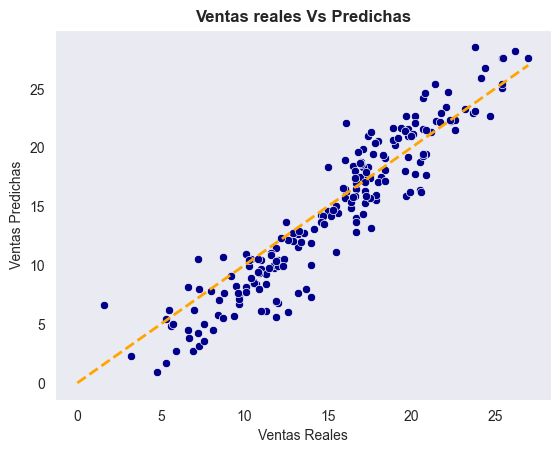

In [17]:
#Visualización de las Predicciones
sns.scatterplot(x=df["Sales"], y=sales_pred_sin_mc, color="darkblue")
plt.plot(range(0,28), range(0,28), color="orange", linestyle="--", linewidth=2)

plt.title("Ventas reales Vs Predichas", fontweight="bold")
plt.xlabel("Ventas Reales")
plt.ylabel("Ventas Predichas")
plt.show()

En comparación con el primer modelo, los puntos están más alejados de la línea naranja de perfección.

In [18]:
#P-values

modelo_sm_sin_mc = sm.OLS(df["Sales"], X).fit()
print(modelo_sm_sin_mc.summary())

                                 OLS Regression Results                                
Dep. Variable:                  Sales   R-squared (uncentered):                   0.977
Model:                            OLS   Adj. R-squared (uncentered):              0.977
Method:                 Least Squares   F-statistic:                              2826.
Date:                Sun, 19 Oct 2025   Prob (F-statistic):                   1.35e-161
Time:                        12:51:29   Log-Likelihood:                         -460.08
No. Observations:                 200   AIC:                                      926.2
Df Residuals:                     197   BIC:                                      936.1
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Usando la librería statsmodels para crear el modelo de regresión, obsérvese que los coeficientes son distintos a los del modelo creado con sklearn. La librería stastsmodels funciona con datos centrados y no centrados, mientras que sklearn asume que los datos están centrados. Por centrados, se refiere a que la recta de regresión cruza por el origen.

Sin el intercepto, el periódico ahora sí tiene una contribución significativa al modelo. Sin el intercepto mejora el ajuste del modelo de un 90 a un 98% (ahora explica el 98% de la variación) y se elimina el problema de la multicolinealidad (Cond. No es menor a 30). Además, se cumple con la normalidad de residuos. 

## Parte 6: Construcción del Modelo (sin variables que no muestran una relación lineal), Evaluación

En el caso de que hayas detectado variables sin una relación lineal con la variable dependiente. Elimina aquellas que presenten esta característica y realiza lo siguiente.

En el caso de que hayas detectado variables sin una relación lineal. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

**Nota:** No es necesario realizar este paso, ya que en el modelo previo sin la constante, las 3 variables tienen una relación lineal significativa con las ventas.

## 7. Conclusiones.

¿Cuál de los tres modelos construidos fue el mejor?
¿Cuál fue el atributo que mas influencia tiene en las ventas?

Se concluye que el mejor modelo fue el <u>segundo sin el intercepto</u>. Aunque es debatible si se cumple con la homocedasticidad (había tendencia lineal decreciente en ventas predichas respecto a los residuales), tuvo un mejor ajuste sin multicolinealidad y con una distribución normal de los residuales. 

De todos los atributos, <u>la radio</u> fue el que mayor influencia tuvo en las ventas.